In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\USER\Desktop\8. Netflix Dataset.csv")

df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


# Question 1: What is the shape of the dataset?

In [12]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (7789, 11)


# Question 2: What are the column names?

In [13]:
print(df.columns)

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='str')


# Question 3: Display first 5 records.

In [14]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


# Question 4: Check dataset information.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Show_Id       7789 non-null   str  
 1   Category      7789 non-null   str  
 2   Title         7789 non-null   str  
 3   Director      5401 non-null   str  
 4   Cast          7071 non-null   str  
 5   Country       7282 non-null   str  
 6   Release_Date  7779 non-null   str  
 7   Rating        7782 non-null   str  
 8   Duration      7789 non-null   str  
 9   Type          7789 non-null   str  
 10  Description   7789 non-null   str  
dtypes: str(11)
memory usage: 669.5 KB


# Question 5: Find missing values.

In [16]:
df.isnull().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

# Question 6: Which Columns Have Missing Values?

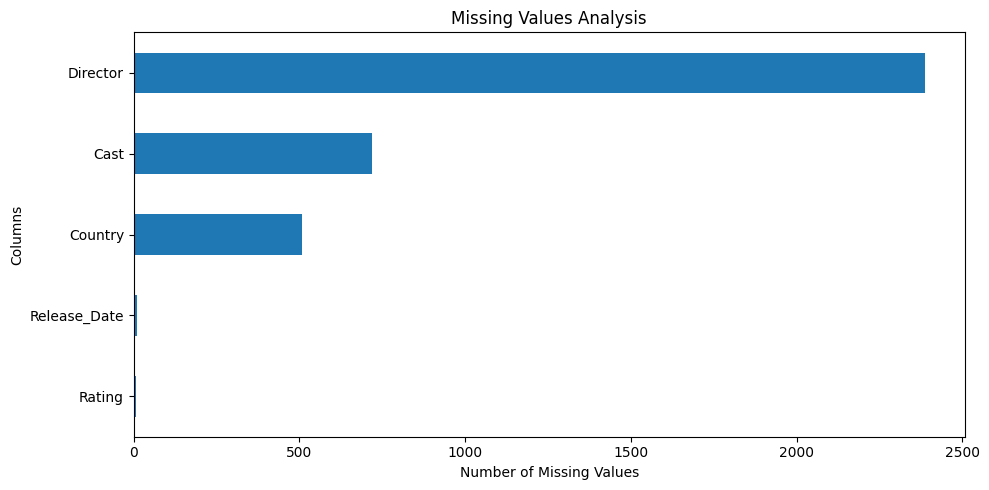

In [25]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10,5))

missing.sort_values(ascending=True).plot(kind='barh')

plt.title("Missing Values Analysis")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")

plt.tight_layout()
plt.show()

# Question 7: What Percentage of Data is Missing in Each Column?

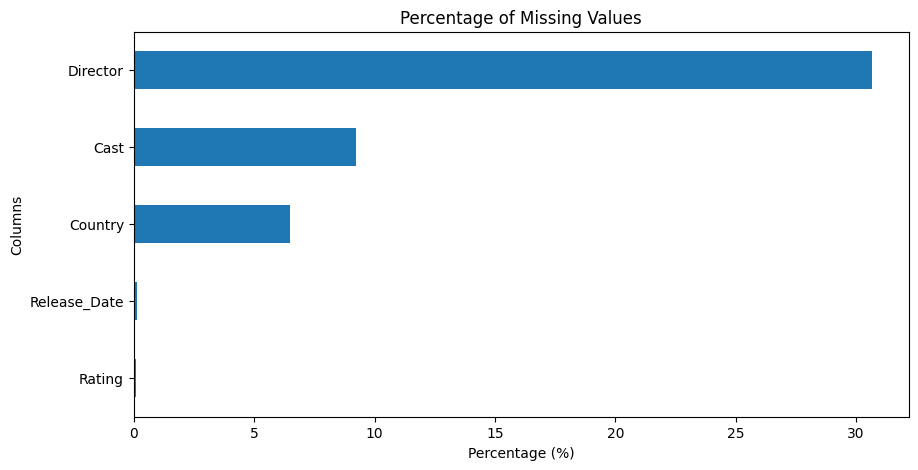

In [26]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values().plot(
    kind='barh',
    figsize=(10,5)
)

plt.title("Percentage of Missing Values")
plt.xlabel("Percentage (%)")
plt.ylabel("Columns")

plt.show()

# Question 8: How Many Movies and TV Shows Are Available?

In [27]:
df['Type'].value_counts()

Type
Documentaries                                                                      334
Stand-Up Comedy                                                                    321
Dramas, International Movies                                                       320
Comedies, Dramas, International Movies                                             243
Dramas, Independent Movies, International Movies                                   215
                                                                                  ... 
Anime Features, International Movies, Sci-Fi & Fantasy                               1
LGBTQ Movies, Thrillers                                                              1
Action & Adventure, Sports Movies                                                    1
Kids' TV, Reality TV, Science & Nature TV                                            1
International TV Shows, Spanish-Language TV Shows, Stand-Up Comedy & Talk Shows      1
Name: count, Length: 492, dtype: int64

# Question 9: Visualize Movies vs TV Shows

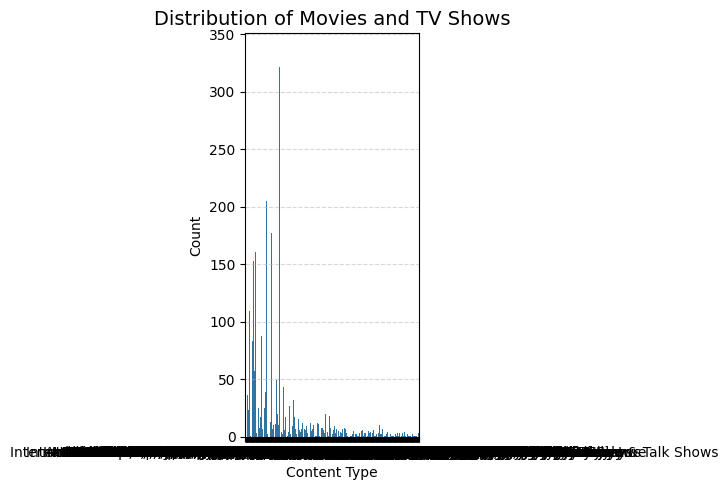

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Type'
)

plt.title("Distribution of Movies and TV Shows", fontsize=14)
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Question 10: Which Are the Top 10 Categories?

In [31]:
df['Category'].value_counts().head(10)

Category
Movie      5379
TV Show    2410
Name: count, dtype: int64

# Question 11: Visualize Top 10 Categories

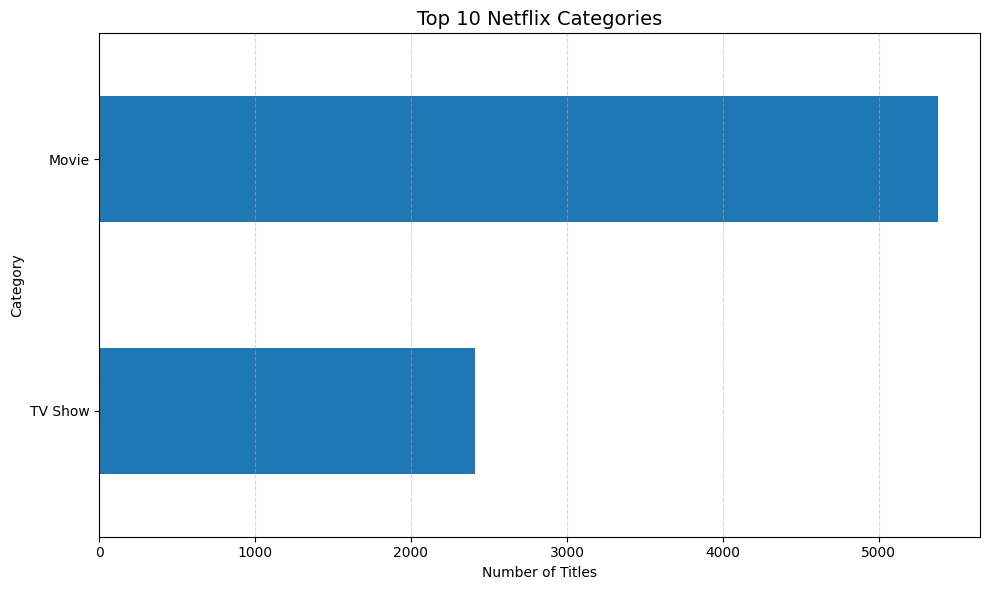

In [42]:
top_categories = df['Category'].value_counts().head(2)

plt.figure(figsize=(10,6))

top_categories.sort_values().plot(
    kind='barh'
)

plt.title("Top 10 Netflix Categories", fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Category")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Question 12: What Is the Distribution of Content Ratings?

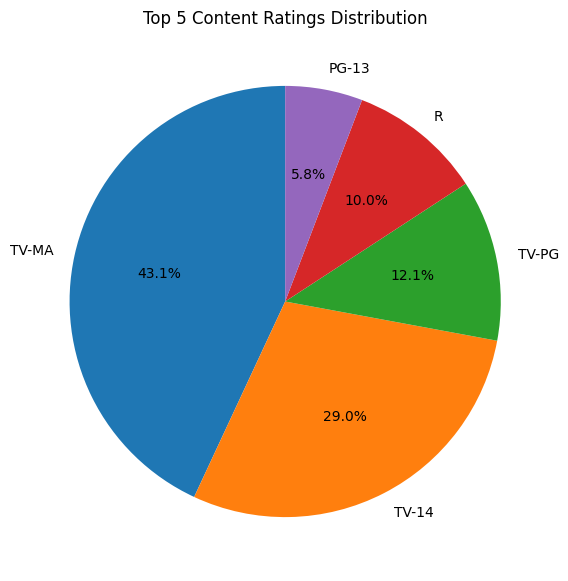

In [33]:
rating_counts = df['Rating'].value_counts().head(5)

plt.figure(figsize=(7,7))

plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 5 Content Ratings Distribution")

plt.show()

# Question 13: What Percentage of Movies and TV Shows Are Available?

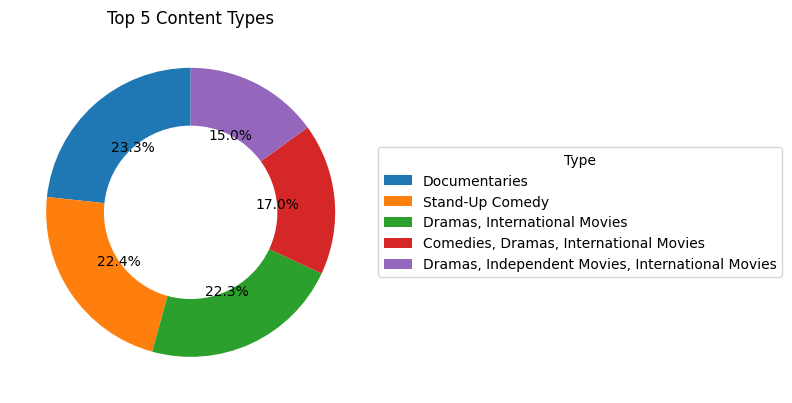

In [36]:
top_types = df['Type'].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top_types,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.legend(
    top_types.index,
    title="Type",
    loc="center left",
    bbox_to_anchor=(1,0.5)
)

plt.title("Top 5 Content Types")

plt.tight_layout()
plt.show()

# Question 14: Which Year Has the Highest Number of Releases?

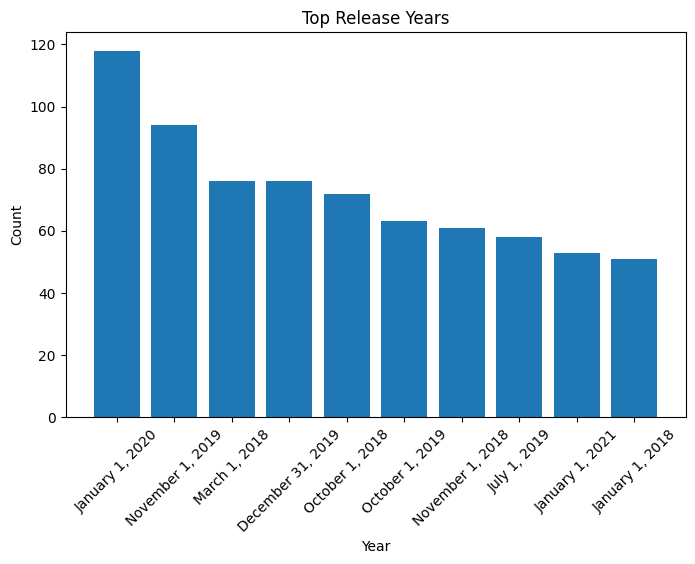

In [41]:
top_years = df['Release_Date'].value_counts().head(10)

plt.figure(figsize=(8,5))

plt.bar(
    top_years.index,
    top_years.values
)

plt.title("Top Release Years")
plt.xlabel("Year")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()